In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Simulation Exercise in Newey and Powell (2003)

## Section 1: Review of Newey and Powell (2003, Econometrica) NP2SLS Estimator

We are interested in recovering the unknown structural equation $g_0(x, z_1)$ from the model:
$$y = g_0(x,z_1) + \epsilon, \quad E[\epsilon|z] = 0, \quad z=(z_1, z_2),$$
where $x \in \mathbb{R}^{d_x \times 1}$ may be endogenous, $z_1 \in \mathbb{R}^{d_1 \times 1}$ and $z_2 \in \mathbb{R}^{d_2 \times 1}$ are vectors of instrument variables. 

Let $w=(x, z_1) \in \mathbb{R}^d$, we may consider $g_0(w) \approx \sum_{j=1}^J \gamma_j p_j(w)$, where $\{p_j(w)\}$ is a sequence of basis function and $\gamma$ is a corresosponding vector of coefficients. It follows $$E[y|z] = \sum_{j=1}^J \gamma_j E[p_j(w)|z].$$
This suggests in the first stage, we estimate $E[p_j(w)|z]$ nonparametrically. In the second stage, we estimate $\gamma$. However naive applying 2SLS is tricky as $E[p_j(w)|z]$ may not have much variance. Their approach is to solve this problem via constrained optimization (regularization). This helps because the problem is to find $\hat{g}$ such that $T \hat{g} \approx \hat{\pi}$, where $\hat{T}$ is a continuos functional $g \rightarrow E[g(x)|Z]$. Assmuing that $g_0$ is in a compact set ensures that $T^{-1}$ is continuous.

Consider the functions of the form $a(w)'\beta + g_1(w)$, where $a(w)$ and $\beta$ are $r \times 1$ vectors of known functions and unknown parameters, $g_1(w)$ and its derivatives are required to be small in the tails. Here $a(w)'\beta$ is a parametric tail, and $g_1(w)$ is nonparametric middle. The parametric part is mostly designed to ensure compactness while allowing $w$ to be unbounded. In practice, we typically just use $a(w)=w$. They propose to optimize the following criterion:

\begin{align}
\beta, \gamma &:= \arg \min_{\beta, \gamma} \sum_{i=1}^n \{y_i - \hat{E}[a|x_i]\beta - \sum_{j=1}^j \gamma_j \hat{E} [p_j | z_i] \}^2/n \\
& \text{ s.t } \beta' \beta \leq B_{\beta}, \quad \gamma' \Lambda_J \gamma \leq  B_1,
\end{align}

where $B_{\beta}$ and $B_1$ are constant, and $\Lambda_J$ is a matrix defined after Equation (3.2) of the paper to restrict the derivative of $g_1$. To estimate the firsrt stage for $\hat{E}[a|x_i]$ and $\hat{E}[p_j | z_i]$, we may choose a cubic spline basis for $z_i$ with K knows, and then run $J+1$ regressions. 



In [2]:
def load_engel95() -> pd.DataFrame:
    """Load the public Engel95 data.

    The Rdatasets mirror includes the exact variables needed for the scalar Engel-curve
    design: food, logexp, logwages, nkids.
    """
    df = pd.read_csv("Engel95.csv")
    # Rdatasets adds an index column named 'rownames'
    if "rownames" in df.columns:
        df = df.drop(columns=["rownames"])
    required = {"food", "logexp", "logwages", "nkids"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Engel95 data are missing required columns: {sorted(missing)}")
    return df

def subset_no_children(df: pd.DataFrame) -> pd.DataFrame:
    out = df.loc[df["nkids"].to_numpy(dtype=float) == 0].copy()
    out = out[["food", "logexp", "logwages", "nkids"]].reset_index(drop=True)
    if len(out) == 0:
        raise ValueError("No no-children observations found in Engel95.")
    return out

df = load_engel95()
df = subset_no_children(df)

In [3]:
import pickle 

with open("./output_engel95_100/engel95_gpt_training_bundle_complete.pkl", "rb") as f:
    bundle = pickle.load(f)

**Example**

In [4]:
bundle[100][1]["gpt_conditional_df"]

,log_total_expenditure,log_gross_earnings,food_share,synthetic_food_share1,synthetic_food_share2
0,5.192338,5.676887,0.194450,0.195,0.215
1,5.306170,5.006139,0.218277,0.215,0.235
2,4.964535,5.646911,0.184253,0.195,0.215
3,5.346218,5.942859,0.151606,0.165,0.185
4,5.511655,5.607355,0.190839,0.185,0.205
...,...,...,...,...,...
95,4.987969,5.402747,0.212355,0.215,0.235
96,5.231337,6.250247,0.151839,0.165,0.185
97,4.614206,5.996278,0.148506,0.185,0.205
98,5.010042,5.983401,0.172589,0.185,0.205


In [5]:
bundle["_meta"]

{'design': 'Engel95 scalar food-share Monte Carlo with decreasing probit h0',
 'calibration': {'subset': 'Engel95 no-children (nkids == 0)',
  'n_source': 628,
  'kde_bandwidth': 'scott',
  'df_m': 7,
  'sigma_v': 0.01,
  'sigma_v_mode': 'fixed',
  'clip_y': True,
  'y_eps': 0.005,
  'h0_params': {'upper': 0.28010913828382933,
   'span': 0.19941468303134482,
   'center': 5.340449224819264,
   'scale': 0.5091455223830568},
  'x_quantiles': {'q05': 4.617472004890442,
   'q50': 5.356916427612305,
   'q95': 6.248513627052307},
  'z_quantiles': {'q05': 5.02422001361847,
   'q50': 5.754127025604248,
   'q95': 6.572941803932189},
  'y_quantiles': {'q05': 0.05007777027785775,
   'q50': 0.16201065480709076,
   'q95': 0.3496167615056037}},
 'k_per_row': 2,
 'Ns': [100],
 'mc': 100,
 'n_test': 100}

In [6]:
def _parse_alpha_value(alpha_str: str) -> float:
    """
    Convert strings like:
      '0'       -> 0.0
      '0.05N'   -> 0.05
      '1.0N'    -> 1.0
      '1N'      -> 1.0
      'N'       -> 1.0
    """
    s = str(alpha_str).strip()
    if s in {"N", "1N", "1.0N", "1.00N"}:
        return 1.0
    if s.endswith("N"):
        return float(s[:-1])
    return float(s)


def _method_sort_key(method: str):
    """
    Sort order for current Engel95 experiment:
      1) PenalizedSplineNPIV
      2) SBETEL(alpha=0)
      3) GPT-SBETEL(alpha>0) in increasing alpha
      4) anything else at the end
    """
    m = str(method)

    if m.startswith("PenalizedSplineNPIV"):
        return (0, 0.0)

    mt = re.fullmatch(r"([^()]+)\(alpha=([^)]+)\)", m)
    if mt is None:
        return (99, m)

    family = mt.group(1).strip().lower()
    alpha = _parse_alpha_value(mt.group(2))

    if family == "sbetel":
        return (1, alpha)
    if family == "gpt-sbetel":
        return (2, alpha)

    return (98, alpha)


def _format_method_label(method: str) -> str:
    """
    Make labels shorter / cleaner for display.
    """
    m = str(method)

    if m.startswith("PenalizedSplineNPIV"):
        return "PenalizedSplineNPIV"

    mt = re.fullmatch(r"([^()]+)\(alpha=([^)]+)\)", m)
    if mt is None:
        return m

    family = mt.group(1).strip()
    alpha = mt.group(2).strip()

    if alpha in {"1.00N", "1.0N", "1N"}:
        alpha = "N"

    return f"{family}(alpha={alpha})"


def _sort_columns(cols):
    """
    Sort columns as:
      Train_RMSE(N=100), Test_RMSE(N=100), Train_RMSE(N=400), Test_RMSE(N=400), ...
    """
    def keyfun(c):
        N = int(re.search(r"N=(\d+)\)", c).group(1))
        is_test = c.startswith("Test_")
        return (N, is_test)

    return sorted(cols, key=keyfun)


def results_csv_to_method_table(obj) -> pd.DataFrame:
    """
    Accept either:
      - path to CSV
      - DataFrame already read from CSV

    Works for:
      1) long CSV with columns: N, method, split, RMSE
      2) wide CSV if you later save one in pivoted form

    Returns a clean table with rows = methods and columns =
      Train_RMSE(N=100), Test_RMSE(N=100), Train_RMSE(N=400), Test_RMSE(N=400), ...
    """
    if isinstance(obj, str):
        df_try = pd.read_csv(obj)
    else:
        df_try = obj.copy()

    required_long = {"N", "method", "split", "RMSE"}
    if required_long.issubset(set(df_try.columns)):
        df = df_try.copy()
        df["method_label"] = df["method"].map(_format_method_label)
        df["col"] = df.apply(
            lambda r: f"{str(r['split']).title()}_RMSE(N={int(r['N'])})",
            axis=1
        )

        out = df.pivot(index="method_label", columns="col", values="RMSE")

        method_order = sorted(out.index, key=_method_sort_key)
        col_order = _sort_columns(out.columns)

        return out.loc[method_order, col_order]

    raise ValueError("Could not detect the expected long-format results CSV.")


def plot_results_long(df_long: pd.DataFrame, split: str = "test", figsize=(8, 5)):
    """
    Plot RMSE vs alpha for current Engel95 methods.

    split: 'train' or 'test'
    """
    df = df_long.copy()
    df = df[df["split"].str.lower() == split.lower()].copy()

    baseline = df[df["method"].str.startswith("PenalizedSplineNPIV")].copy()
    sbetel0 = df[df["method"] == "SBETEL(alpha=0)"].copy()
    gpt = df[df["method"].str.startswith("GPT-SBETEL")].copy()

    plt.figure(figsize=figsize)

    # baseline horizontal line
    if not baseline.empty:
        y0 = baseline["RMSE"].iloc[0]
        plt.axhline(y0, linestyle="--", label="PenalizedSplineNPIV")

    # alpha=0 point
    if not sbetel0.empty:
        plt.scatter([0.0], sbetel0["RMSE"].values, s=70, label="SBETEL(alpha=0)")

    # GPT-SBETEL curve
    if not gpt.empty:
        gpt = gpt.copy()
        gpt["alpha"] = gpt["method"].str.extract(r"alpha=([^)]+)")[0].map(_parse_alpha_value)
        gpt = gpt.sort_values("alpha")
        plt.plot(gpt["alpha"], gpt["RMSE"], marker="o", label="GPT-SBETEL")

    plt.xlabel(r"$\alpha/N$")
    plt.ylabel(f"{split.title()} RMSE")
    plt.title(f"Engel95 results ({split.title()})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
result_100 = pd.read_csv("engel95_npiv_vs_gpt_sbetel_long_100.csv")
method_table = results_csv_to_method_table(result_100)
method_table

col,Train_RMSE(N=100),Test_RMSE(N=100)
method_label,,
PenalizedSplineNPIV,0.028102,0.031267
SBETEL(alpha=0),0.034058,0.036756
GPT-SBETEL(alpha=0.01N),0.028746,0.032690
GPT-SBETEL(alpha=0.05N),0.028666,0.031955
GPT-SBETEL(alpha=0.10N),0.025104,0.027120
GPT-SBETEL(alpha=0.20N),0.026181,0.028971
GPT-SBETEL(alpha=0.30N),0.026302,0.028549
GPT-SBETEL(alpha=0.50N),0.024293,0.026675


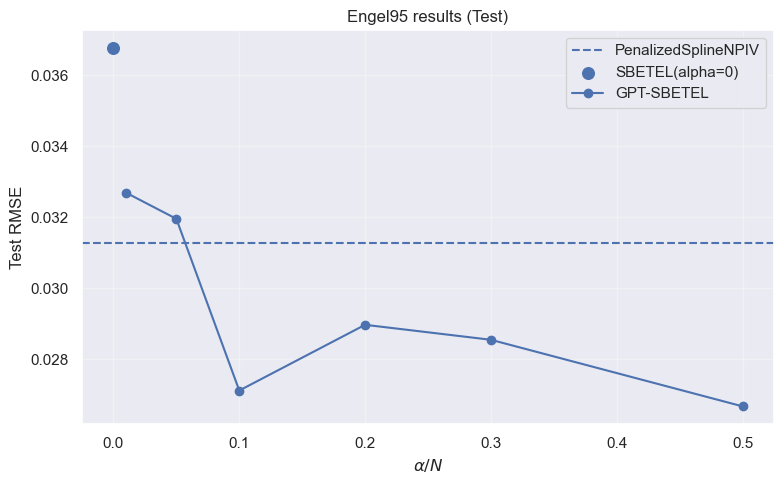

In [7]:
plot_results_long(result_100, split="test")

In [8]:
result_400 = pd.read_csv("engel95_npiv_vs_gpt_sbetel_long_400.csv")
method_table = results_csv_to_method_table(result_400)
method_table

col,Train_RMSE(N=400),Test_RMSE(N=400)
method_label,,
PenalizedSplineNPIV,0.016203,0.017169
SBETEL(alpha=0),0.016092,0.016932
GPT-SBETEL(alpha=0.01N),0.016080,0.016927
GPT-SBETEL(alpha=0.05N),0.016071,0.016904
GPT-SBETEL(alpha=0.10N),0.016096,0.016919
GPT-SBETEL(alpha=0.20N),0.016174,0.016955
GPT-SBETEL(alpha=0.30N),0.016320,0.017091
GPT-SBETEL(alpha=0.50N),0.016628,0.017334


## Convex Hull

In [9]:
with open("convex_hull_diagnostics.pkl", "rb") as f:
    out = pickle.load(f)
out.keys()

dict_keys(['meta', 'data', 'target', 'npiv', 'alpha0', 'alpha_pos'])

In [10]:
def _get_x_train(out):
    if "data" in out and "x_train" in out["data"]:
        return np.asarray(out["data"]["x_train"], float)
    if "sample" in out and "x_train" in out["sample"]:
        return np.asarray(out["sample"]["x_train"], float)
    if "x_train" in out:
        return np.asarray(out["x_train"], float)
    raise KeyError("Could not find x_train in diagnostics pickle.")


def _get_curve_draws(run):
    for key in ["curve_grid_draws_used", "curve_grid_draws", "grid_draws"]:
        if key in run:
            arr = np.asarray(run[key], float)
            if arr.ndim == 2:
                return arr
    raise KeyError("Could not find draw-level curve matrix in run dict.")


def _get_feasible(run):
    if "feasible" in run:
        return np.asarray(run["feasible"], bool)
    draws = _get_curve_draws(run)
    return np.ones(draws.shape[0], dtype=bool)


def _sorted_mass_draws(run):
    return np.asarray(run["p_sorted_draws"], float)


def _label(run, fallback):
    return run["label"] if "label" in run else fallback

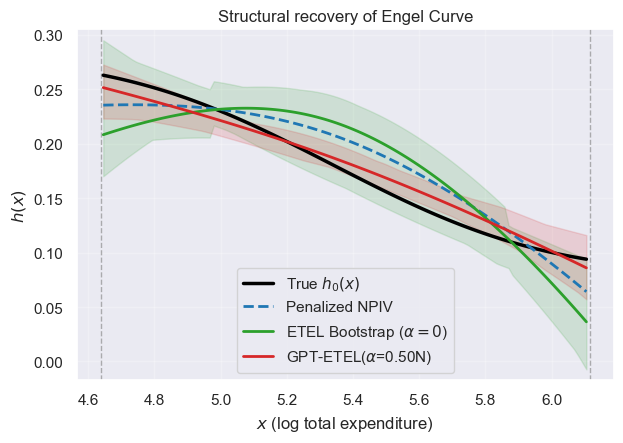

In [21]:
def plot_curve_recovery_clean(
    out,
    alpha_key="0.5000",
    support_q=(0.10, 0.90),
    band_q=(0.25, 0.75),
    pdf_path=None,  
):
    xg = np.asarray(out["target"]["x_grid"], float)
    h0 = np.asarray(out["target"]["h0_grid"], float)
    x_train = _get_x_train(out)

    ql, qh = support_q
    lo_x, hi_x = np.quantile(x_train, [ql, qh])
    mask = (xg >= lo_x) & (xg <= hi_x)

    xplot = xg[mask]
    h0plot = h0[mask]

    # NPIV
    npiv = np.asarray(out["npiv"]["curve_grid"], float)[mask]

    # alpha = 0
    run0 = out["alpha0"]
    draws0 = _get_curve_draws(run0)[_get_feasible(run0)][:, mask]
    mean0 = np.nanmean(draws0, axis=0)
    lo0 = np.nanquantile(draws0, band_q[0], axis=0)
    hi0 = np.nanquantile(draws0, band_q[1], axis=0)

    # chosen alpha > 0
    runa = out["alpha_pos"][alpha_key]
    drawsa = _get_curve_draws(runa)[_get_feasible(runa)][:, mask]
    meana = np.nanmean(drawsa, axis=0)
    loa = np.nanquantile(drawsa, band_q[0], axis=0)
    hia = np.nanquantile(drawsa, band_q[1], axis=0)

    fig, ax = plt.subplots(figsize=(6.4, 4.6))

    ax.axvline(lo_x, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.axvline(hi_x, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    ax.plot(xplot, h0plot, color="black", linewidth=2.5, label=r"True $h_0(x)$")
    ax.plot(xplot, npiv, color="tab:blue", linestyle="--", linewidth=2, label="Penalized NPIV")

    ax.plot(xplot, mean0, color="tab:green", linewidth=2, label=r"ETEL Bootstrap ($\alpha=0$)")
    ax.fill_between(xplot, lo0, hi0, color="tab:green", alpha=0.15)

    temp_label = _label(runa, f"alpha={alpha_key}")
    temp_label = temp_label.replace("S", "")
    temp_label = temp_label.replace("B", "")
    temp_label = temp_label.replace("alpha", r"$\alpha$")
    ax.plot(xplot, meana, color="tab:red", linewidth=2, label=temp_label)
    ax.fill_between(xplot, loa, hia, color="tab:red", alpha=0.15)

    ax.set_xlabel(r"$x$ (log total expenditure)")
    ax.set_ylabel(r"$h(x)$")

    title = "Structural recovery of Engel Curve"
    ax.set_title(title)

    ys = np.concatenate([h0plot, npiv, mean0, lo0, hi0, meana, loa, hia])
    ylo = np.nanmin(ys) - 0.01
    yhi = np.nanmax(ys) + 0.01
    ax.set_ylim(ylo, yhi)

    ax.legend(frameon=True)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if pdf_path is not None:
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    plt.show()


plot_curve_recovery_clean(
    out,
    alpha_key="0.5000",
    support_q=(0.05, 0.95),
    band_q=(0.02, 0.98),
    pdf_path="curve_recovery.pdf",
)

In [25]:
def plot_cumulative_topk_mass(
    out,
    alpha_keys=("0.1000", "0.5000"),
    top_k=10,
    pdf_path=None,
    show=True,
):
    fig, ax = plt.subplots(figsize=(7, 5))

    # alpha = 0
    run0 = out["alpha0"]
    p0 = _sorted_mass_draws(run0)[_get_feasible(run0), :top_k]
    c0 = np.cumsum(p0, axis=1)
    mean0 = np.nanmean(c0, axis=0)
    lo0 = np.nanquantile(c0, 0.10, axis=0)
    hi0 = np.nanquantile(c0, 0.90, axis=0)
    k = np.arange(1, top_k + 1)

    ax.plot(k, mean0, color="tab:green", linewidth=2, label=r"ETEL Bootstrap($\alpha=0$)")
    ax.fill_between(k, lo0, hi0, color="tab:green", alpha=0.20)

    # alpha > 0
    colors = ["tab:red", "tab:blue", "tab:orange", "tab:purple"]
    for key, color in zip(alpha_keys, colors):
        if key not in out["alpha_pos"]:
            continue
        run = out["alpha_pos"][key]
        p = _sorted_mass_draws(run)[_get_feasible(run), :top_k]
        c = np.cumsum(p, axis=1)
        mean = np.nanmean(c, axis=0)
        lo = np.nanquantile(c, 0.25, axis=0)
        hi = np.nanquantile(c, 0.75, axis=0)

        temp_label = _label(run, f"alpha={key}")
        temp_label = temp_label.replace("S", "")
        temp_label = temp_label.replace("B", "")
        temp_label = temp_label.replace("alpha", r"$\alpha$")
        ax.plot(k, mean, color=color, linewidth=2, label=temp_label)
        ax.fill_between(k, lo, hi, color=color, alpha=0.15)

    ax.set_xlabel(r"Top-$k$ support points")
    ax.set_ylabel(r"Cumulative implied mass $\sum_{j=1}^k p_{(j)}$")
    ax.set_title("Concentration of ETEL-implied masses")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

    if pdf_path is not None:
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

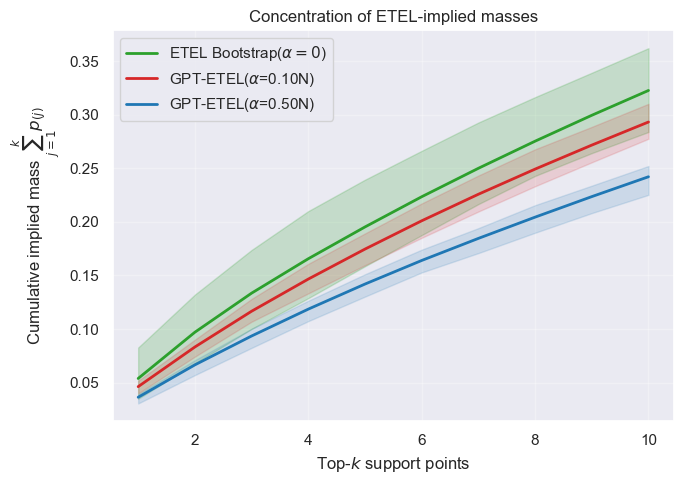

In [26]:
fig, ax = plot_cumulative_topk_mass(
    out,
    alpha_keys=("0.1000", "0.5000"),
    top_k=10,
    pdf_path="cumulative_topk_mass.pdf",
)